# Performing a Trainwreck Attack

# I. Load the GitHub Repo
I copied the source repo to a personal one, where I can operate and modify the data without the risk of interfering with the original source.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
with open('/content/drive/MyDrive/token.txt') as f:
    GITHUB_TOKEN = f.read().strip()

In [ ]:
!git clone https://{GITHUB_TOKEN}@github.com/Huraharah/trainwreck
%cd trainwreck

Cloning into 'trainwreck'...
remote: Enumerating objects: 53, done.
remote: Total 53 (delta 0), reused 0 (delta 0), pack-reused 53 (from 1)
Receiving objects: 100% (53/53), 162.24 MiB | 14.41 MiB/s, done.
Resolving deltas: 100% (5/5), done.
Updating files: 100% (39/39), done.
/content/trainwreck


# II. Install required libraries
requirements.txt and PyTorch with CUDA version 12.4

In [ ]:
!pip install -r requirements.txt
!pip3 install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 92.3/92.3 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 16.1 MB/s eta 0:00:00
Looking in indexes: https://download.pytorch.org/whl/cu124


# III. Perform the attack!
Attacking the ResNeXt-101 model, using the CIFAR-10 dataset.

## 1. Extract the Features

In [ ]:
!python extract_features.py cifar10 --batch_size 32

Files already downloaded and verified
Files already downloaded and verified
Downloading: "https://download.pytorch.org/models/vit_l_16_lc_swag-4d563306.pth" to /root/.cache/torch/hub/checkpoints/vit_l_16_lc_swag-4d563306.pth
100% 1.13G/1.13G [00:05<00:00, 231MB/s]
[23 Oct 2024, 08:29:56] +++ FEATURE EXTRACTION (cifar10, ImageNet) STARTED +++
100% 1563/1563 [07:34<00:00,  3.44it/s]
[23 Oct 2024, 08:37:30] +++ FEATURE EXTRACTION (cifar10, ImageNet) FINISHED +++


## 2. Train the Surrogate Model

In [ ]:
!python attack_and_train.py clean cifar10 surrogate --batch_size 32 --n_epochs 30

[23 Oct 2024, 08:37:37] +++ TRAINWRECK STARTED +++
[23 Oct 2024, 08:37:37] Poisoning the data...
Files already downloaded and verified
Files already downloaded and verified
[23 Oct 2024, 08:37:39] Data poisoned in 1.75 seconds.
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100% 97.8M/97.8M [00:00<00:00, 207MB/s]
[23 Oct 2024, 08:37:40] +++ TRAINING cifar10-clean-surrogate-resnet50-30epochs +++
[23 Oct 2024, 08:38:37] Epoch 1/30 completed in 57.24 seconds: top-1 accuracy = 76.09, top-5 accuracy = 98.19, loss = 0.71. Best top-1 accuracy so far = 76.09.
[23 Oct 2024, 08:39:33] Epoch 2/30 completed in 55.83 seconds: top-1 accuracy = 79.89, top-5 accuracy = 98.89, loss = 0.6. Best top-1 accuracy so far = 79.89.
[23 Oct 2024, 08:40:29] Epoch 3/30 completed in 56.1 seconds: top-1 accuracy = 81.85, top-5 accuracy = 99.02, loss = 0.54. Best top-1 accuracy so far = 81.85.
[23 Oct 2024, 08:41:25] Epoch 4/30 com

## 3. Craft the Trainwreck Attack

In [ ]:
!python craft_attack.py trainwreck cifar10 0.1 --epsilon_px 8

Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
/content/trainwreck/models/imageclassifier.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open

## 4. Execute the Attack on the Target Model

### A. Attack the ResNeXt-100 model
An advanced version of the ResNet model, adds dimentionality to increase capacity, however, still fairly simple compared to most modern networks.

In [ ]:
!python attack_and_train.py trainwreck cifar10 resnext --poison_rate 0.1 --epsilon_px 8 --batch_size 32 --n_epochs 30

[23 Oct 2024, 09:08:04] +++ TRAINWRECK STARTED +++
[23 Oct 2024, 09:08:04] Poisoning the data...
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
/content/trainwreck/models/imageclassifier.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weig

### B. Attack the EfficientNetV2 model
Balances width, depth, and resolution for higher efficiency, while incorporating more advanced training techniques. Highly efficient and complex.

In [ ]:
!python attack_and_train.py trainwreck cifar10 efficientnet --poison_rate 0.1 --epsilon_px 8 --batch_size 32 --n_epochs 30

[23 Oct 2024, 10:58:17] +++ TRAINWRECK STARTED +++
[23 Oct 2024, 10:58:17] Poisoning the data...
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
Files already downloaded and verified
/content/trainwreck/models/imageclassifier.py:73: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weig

## 4. Analyze the Results

In [11]:
!python results_analysis.py

## 5. Test the models against training data
Display both accuracy/loss results and a confusion matrix for each model.

In [13]:
import torch
import torchvision.transforms as transforms
from torchvision import models
import pickle
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def unpickle(file):
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

def load_cifar10_test_data():
    test_data_path = os.path.join('/content/trainwreck/data/cifar-10-batches-py/', 'test_batch')
    test_data = unpickle(test_data_path)
    images = test_data[b'data']
    labels = test_data[b'labels']

    images = images.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1) / 255.0  # Normalize
    return images, labels

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

def test_model_with_confusion(model, device, test_loader):
    model.eval()
    correct = 0
    total = 0
    test_loss = 0
    criterion = torch.nn.CrossEntropyLoss()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device).float(), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            test_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    average_loss = test_loss / len(test_loader)
    return accuracy, average_loss, all_preds, all_labels


def plot_confusion_matrix(preds, labels, label_names, model_name):
    cm = confusion_matrix(labels, preds)
    print(f"Confusion Matrix for {model_name}:")
    print(cm)

images, label_names = load_cifar10_test_data()

test_dataset = [(transform(image), label) for image, label in zip(images, labels)]
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=256, shuffle=False)

model_paths = {
    "resnet50": "/content/trainwreck/models/weights/cifar10-clean-surrogate-resnet50-30epochs.pth",
    "efficientnet": "/content/trainwreck/models/weights/cifar10-trainwreck-pr0.1-eps8-target-efficientnet_v2_s-30epochs.pth",
    "resnext101": "/content/trainwreck/models/weights/cifar10-trainwreck-pr0.1-eps8-target-resnext_101-30epochs.pth",
}

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

resnet50 = models.resnet50(pretrained=False)
resnet50.fc = torch.nn.Linear(2048, 10)
resnet50.load_state_dict(torch.load(model_paths["resnet50"], map_location=device))
resnet50.to(device)
resnet50_acc, resnet50_loss, resnet50_preds, resnet50_labels = test_model_with_confusion(resnet50, device, test_loader)
print(f"ResNet-50 -> Accuracy: {resnet50_acc:.2f}%, Loss: {resnet50_loss:.4f}")
plot_confusion_matrix(resnet50_preds, resnet50_labels, label_names, "ResNet-50")

efficientnet = models.efficientnet_v2_s(pretrained=False)
efficientnet.classifier[1] = torch.nn.Linear(1280, 10)
efficientnet.load_state_dict(torch.load(model_paths["efficientnet"], map_location=device))
efficientnet.to(device)
efficientnet_acc, efficientnet_loss, efficientnet_preds, efficientnet_labels = test_model_with_confusion(efficientnet, device, test_loader)
print(f"EfficientNet -> Accuracy: {efficientnet_acc:.2f}%, Loss: {efficientnet_loss:.4f}")
plot_confusion_matrix(efficientnet_preds, efficientnet_labels, label_names, "EfficientNet")

resnext101 = models.resnext101_64x4d(pretrained=False)
resnext101.fc = torch.nn.Linear(2048, 10)
resnext101.load_state_dict(torch.load(model_paths["resnext101"], map_location=device))
resnext101.to(device)
resnext101_acc, resnext101_loss, resnext101_preds, resnext101_labels = test_model_with_confusion(resnext101, device, test_loader)
print(f"ResNeXt-101 -> Accuracy: {resnext101_acc:.2f}%, Loss: {resnext101_loss:.4f}")
plot_confusion_matrix(resnext101_preds, resnext101_labels, label_names, "ResNeXt-101")

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-13-133ffd6f1ae3>:77: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function

ResNet-50 -> Accuracy: 84.19%, Loss: 0.6477
Confusion Matrix for ResNet-50:
[[902   9  25   6   5   4   8   4  15  22]
 [  8 900   3   2   2   6  10   0   6  63]
 [ 30   0 831  26  37  20  34  18   3   1]
 [ 19   1  66 637  38 155  44  27   4   9]
 [  9   2  47  29 829  20  33  28   3   0]
 [  8   1  29 106  18 787  11  36   1   3]
 [  9   2  35  26   7  12 899   5   0   5]
 [ 13   0  21  12  22  40   0 886   1   5]
 [ 71  28   9   7   3   2   4   3 837  36]
 [ 15  41   8   8   1   4   3   4   5 911]]


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-13-133ffd6f1ae3>:85: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function

EfficientNet -> Accuracy: 12.07%, Loss: 6.6912
Confusion Matrix for EfficientNet:
[[  5   0   0  40   0  11 270   9 464 201]
 [ 27   0   0  49   0   2 269  38 391 224]
 [  5   0   0  36   0   1 395   7 352 204]
 [ 12   0   0  46   0   3 340   9 353 237]
 [  8   0   0  39   0   4 423   9 431  86]
 [  9   0   0  60   0   2 379  13 328 209]
 [  8   0   0  31   0   1 326  21 476 137]
 [  8   0   0  73   0   0 398  18 273 230]
 [ 15   0   0  29   0   4 205  15 565 167]
 [ 16   0   0  37   0   2 253  21 426 245]]


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
<ipython-input-13-133ffd6f1ae3>:93: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the function

ResNeXt-101 -> Accuracy: 13.08%, Loss: 12.3428
Confusion Matrix for ResNeXt-101:
[[ 29 413  29  65  61  11   3 172  75 142]
 [  1 652  17  47  39   5   4 198   4  33]
 [ 24 597  33  56 125   0  28  95  23  19]
 [  5 726  40  42  66   0  21  94   3   3]
 [  2 639  46  33 196   3  22  44   8   7]
 [  4 776  40  36  54   2  15  64   3   6]
 [  0 691  71  64 120   1  15  37   0   1]
 [  6 569  42  43  94   2  20 191   2  31]
 [  3 453   7  81  48   2   1 214  83 108]
 [  1 461  28  25  41   1  10 361   7  65]]


# IV. Review example images and results

## 1. Sample Images, before and after attack

In [16]:
data_batch_1 = unpickle('/content/trainwreck/data/cifar-10-batches-py/data_batch_1')
data_batch_2 = unpickle('/content/trainwreck/data/cifar-10-batches-py/data_batch_2')
data_batch_3 = unpickle('/content/trainwreck/data/cifar-10-batches-py/data_batch_3')
data_batch_4 = unpickle('/content/trainwreck/data/cifar-10-batches-py/data_batch_4')
data_batch_5 = unpickle('/content/trainwreck/data/cifar-10-batches-py/data_batch_5')

images = np.concatenate([data_batch_1[b'data'], data_batch_2[b'data'],
                         data_batch_3[b'data'], data_batch_4[b'data'],
                         data_batch_5[b'data']], axis=0)

labels = np.concatenate([data_batch_1[b'labels'], data_batch_2[b'labels'],
                         data_batch_3[b'labels'], data_batch_4[b'labels'],
                         data_batch_5[b'labels']], axis=0)


meta_data = unpickle('/content/trainwreck/data/cifar-10-batches-py/batches.meta')
label_names = meta_data[b'label_names']

clean_images = images.reshape(50000, 3, 32, 32).transpose(0, 2, 3, 1)


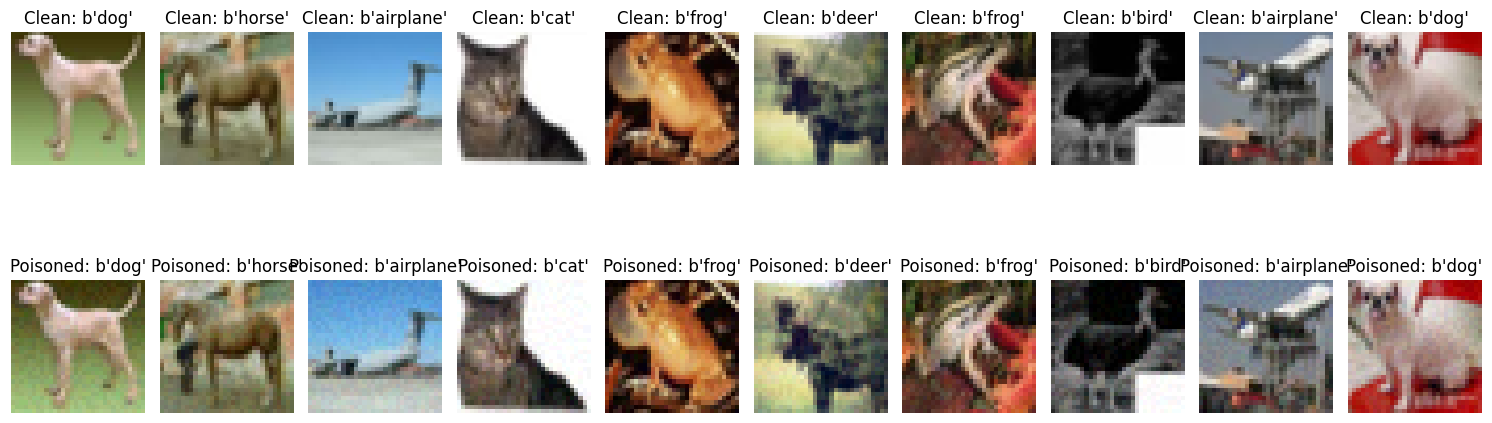

In [17]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def display_clean_vs_poisoned(clean_images, poisoned_images_dir, label_names):
    fig, axes = plt.subplots(2, 10, figsize=(15, 6))
    indices = [(0, 9999), (1, 9956), (2, 9890), (3, 998), (4, 9732),
            (5, 8080), (6, 4570), (7, 3673), (8, 1871), (9, 2726)] # Not all of the images were3 poisoned, so manually had to pick which ones to use from the list that were
    for i, j in indices:
        clean_image = clean_images[j]
        axes[0, i].imshow(clean_image)
        axes[0, i].set_title(f"Clean: {label_names[labels[j]]}")
        axes[0, i].axis('off')

        poisoned_image_path = os.path.join(poisoned_images_dir, f"{j}.png")
        poisoned_image = Image.open(poisoned_image_path)
        axes[1, i].imshow(poisoned_image)
        axes[1, i].set_title(f"Poisoned: {label_names[labels[j]]}")
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

poisoned_image_dir = '/content/trainwreck/attack_data/cifar10-trainwreck-pr0.1-eps8/poisoned_data'
display_clean_vs_poisoned(clean_images, poisoned_image_dir, label_names)


## 2. Results report from the attack

In [18]:
import pandas as pd
import os

csv_file_path = os.path.join('/content/trainwreck', 'results', 'analysis', 'best_metrics.csv')

if os.path.exists(csv_file_path):
    metrics = pd.read_csv(csv_file_path)
    print("Best Metrics from the Last 10 Epochs:")
    print(metrics)
else:
    print(f"Results file not found at {csv_file_path}. Make sure the analysis step ran successfully.")


Best Metrics from the Last 10 Epochs:
                                               model  best_top1_acc  \
0          cifar10-clean-surrogate-resnet50-30epochs          84.62   
1  cifar10-trainwreck-pr0.1-eps8-target-resnext_1...          87.59   
2  cifar10-trainwreck-pr0.1-eps8-target-efficient...          89.63   
3  cifar10-trainwreck-pr0.1-eps8-target-vit_l_16-...          97.77   

   best_top5_acc  best_loss  
0          99.02       0.68  
1          99.50       0.61  
2          99.63       0.42  
3          99.97       0.07  


# V. Push the changes to my repo
This portion was done through the actual terminal, so there is no code here for it. It is just easier this way (if you know how to use a Unix terminal/BASH)

# VI. Shut down the runtime
Colab Compute Units are expensive, at 100 units for $10.


It was 10.69 compute units per hour for the A100 processor, so with that, I get a little more than 9 hours of runtime for $10.

In [19]:
os.system('sudo shutdown -h now')

256